<a href="https://colab.research.google.com/github/karthikakp-gif/internship/blob/main/karthikakpillai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB
None
       experience_years   skills_count  certifications         salary
count     250000.000000  250000.000000   250000.000000  250000.000000
mean          10.005408       9.997812        2.491928  145718.080524
std            6.060602       5.479288        1.706475   37

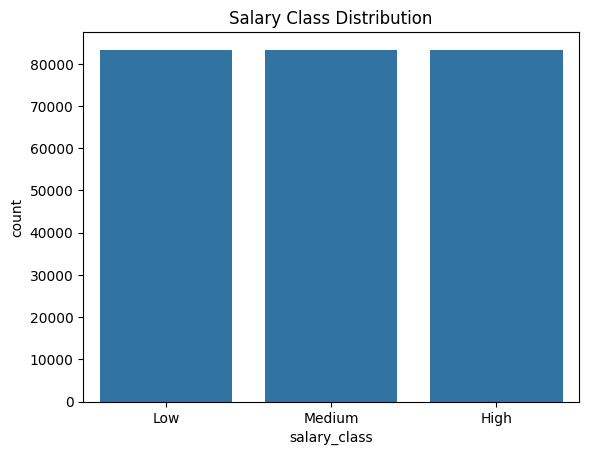

Logistic Regression Accuracy: 0.58484
Decision Tree Accuracy: 0.84022
Random Forest Accuracy: 0.87796


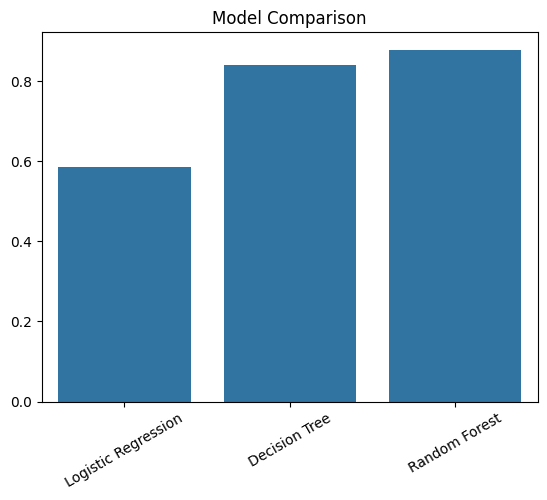

Final Model Accuracy: 0.87638
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     16685
           1       0.92      0.89      0.91     16560
           2       0.81      0.83      0.82     16755

    accuracy                           0.88     50000
   macro avg       0.88      0.88      0.88     50000
weighted avg       0.88      0.88      0.88     50000



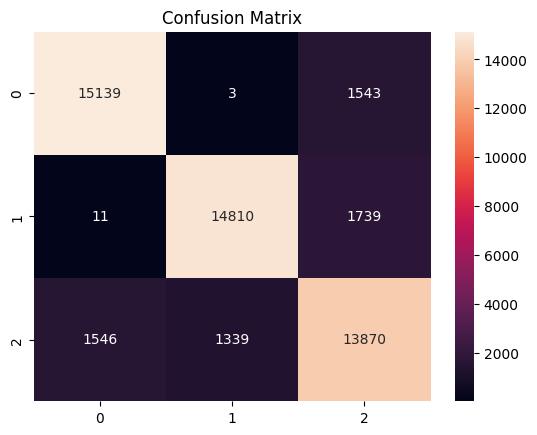

"\nimport streamlit as st\nimport pickle\nimport numpy as np\n\nmodel = pickle.load(open('model.pkl', 'rb'))\n\nst.title('Salary Classification App')\n\n# Example inputs (customize based on dataset)\nexperience = st.number_input('Experience Years')\n\nif st.button('Predict'):\n    prediction = model.predict([[experience]])\n    st.write('Predicted Salary Class:', prediction)\n"

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

try:
    df = pd.read_csv('job_salary_prediction_dataset.csv')
    df.head()
except FileNotFoundError:
    print("Error: 'job_salary_prediction_dataset.csv' not found.")
    print("Please make sure the dataset is uploaded to your Colab environment or provide the correct path.")
    print("You can upload it via the 'Files' tab on the left sidebar, or download it using `!wget` or `!gdown` if it's hosted online.")
    # The program will exit here if the file is not found to prevent further errors.
    exit()

#  Basic Info
print(df.info())
print(df.describe())

# Create Target Variable (Classification)

df['salary_class'] = pd.qcut(df['salary'], q=3, labels=['Low','Medium','High'])

df.drop('salary', axis=1, inplace=True)

# EDA

plt.figure()
sns.countplot(x='salary_class', data=df)
plt.title('Salary Class Distribution')
plt.show()

# Handle Categorical Variables

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df['salary_class'] = le.fit_transform(df['salary_class'])

# Feature & Target Split

X = df.drop('salary_class', axis=1)
y = df['salary_class']

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling

scaler = StandardScaler() # Changed sar to scaler for consistency
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Building

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc}")

# Model Comparison

plt.figure()
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title('Model Comparison')
plt.xticks(rotation=30)
plt.show()

# Hyperparameter Tuning (Random Forest)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

# Final Evaluation

y_pred = best_model.predict(X_test)

print("Final Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

import pickle
pickle.dump(best_model, open('model.pkl', 'wb'))

"""
import streamlit as st
import pickle
import numpy as np

model = pickle.load(open('model.pkl', 'rb'))

st.title('Salary Classification App')

# Example inputs (customize based on dataset)
experience = st.number_input('Experience Years')

if st.button('Predict'):
    prediction = model.predict([[experience]])
    st.write('Predicted Salary Class:', prediction)
"""